logistic regression over ad text to score each ad's probability of being political content. labels come from the curated hashtag csvs from nb 04b — ads carrying a known-political hashtag are positives, ads carrying a known-non-political hashtag are negatives. hashtags themselves are stripped from the text before vectorising so the model has to learn from the surrounding prose, not the labels. then score every v3 advocacy ad and aggregate per advertiser per week to look for pivot patterns.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, lit, lower, regexp_replace, concat_ws, array_join, broadcast,
    sum as spark_sum, count as spark_count, date_trunc, desc, abs as spark_abs,
    mean as spark_mean,
)
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer, StopWordsRemover, CountVectorizer, IDF,
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

spark = SparkSession.builder \
    .appName('FB_API_election_content_clf') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/16 04:41:19 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
V3_PATH = '/user/s3348393/main/preprocessing/v3/parquet'
POLITICAL_CSV     = '../data/hashtags_political.csv'
NON_POLITICAL_CSV = '../data/hashtags_non_political.csv'
BANDS_CSV         = '../data/all_bylines_bands.csv'   # used for downstream comparison only
ELECTION_DATE = pd.Timestamp('2022-05-21')
WINDOW_START = pd.Timestamp('2021-11-21')
WINDOW_END   = pd.Timestamp('2022-11-21')

# hot zone is only used downstream for FP/FN checks and pivot detection.
HOT_ZONE_WEEKS = 4
hot_start = (ELECTION_DATE - pd.Timedelta(weeks=HOT_ZONE_WEEKS)).date().isoformat()
hot_end   = (ELECTION_DATE + pd.Timedelta(weeks=HOT_ZONE_WEEKS)).date().isoformat()

load v3 advocacy ads, detect political and non-political hashtag presence per ad, then strip the hashtags from the text so the model learns from the surrounding prose, not the labels. also attach band labels from nb 05 for downstream comparison.

In [3]:
import re

v3 = spark.read.parquet(V3_PATH).filter(col('match_type').isNull())

# combine body + title arrays into one raw text blob, lowercase.
v3 = v3.withColumn('raw_text', lower(concat_ws(' ',
    array_join('creative_bodies', ' '),
    array_join('creative_link_titles', ' '))))
v3 = v3.filter(col('raw_text').isNotNull() & (col('raw_text') != ''))

# load curated hashtag lists.
political_hashtags     = set(pd.read_csv(POLITICAL_CSV)['hashtag'].str.lower())
non_political_hashtags = set(pd.read_csv(NON_POLITICAL_CSV)['hashtag'].str.lower())
print(f'Political hashtags loaded:     {len(political_hashtags)}')
print(f'Non-political hashtags loaded: {len(non_political_hashtags)}')

def _make_hashtag_regex(tags):
    if not tags:
        return r'(?!.*)'  # never matches
    return r'#(' + '|'.join(re.escape(t) for t in tags) + r')\b'

pol_re = _make_hashtag_regex(political_hashtags)
non_re = _make_hashtag_regex(non_political_hashtags)

v3 = v3.withColumn('has_political_hashtag',     col('raw_text').rlike(pol_re))
v3 = v3.withColumn('has_non_political_hashtag', col('raw_text').rlike(non_re))

# strip all hashtags from text before further processing — the model must learn
# from the prose, not from the hashtags themselves (which are the labels).
v3 = v3.withColumn('text', regexp_replace(col('raw_text'), r'#\w+', ' '))
v3 = v3.withColumn('text', regexp_replace(col('text'), r'[^a-z\s]', ' '))

# attach band labels for downstream comparison only.
try:
    bands_pdf = pd.read_csv(BANDS_CSV)[['bylines', 'band']]
    bands_sdf = spark.createDataFrame(bands_pdf)
    v3 = v3.join(broadcast(bands_sdf), 'bylines', 'left')
    have_bands = True
except FileNotFoundError:
    v3 = v3.withColumn('band', lit(None).cast('string'))
    have_bands = False
    print('Bands csv not found — band column will be null.')

v3 = v3.cache()
print(f'\nAdvocacy ads with text: {v3.count():,}')
print('\nHashtag-tag flags:')
v3.groupBy('has_political_hashtag', 'has_non_political_hashtag').count().show()

Political hashtags loaded:     210
Non-political hashtags loaded: 286


26/05/16 04:41:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



Advocacy ads with text: 95,230

Hashtag-tag flags:
+---------------------+-------------------------+-----+
|has_political_hashtag|has_non_political_hashtag|count|
+---------------------+-------------------------+-----+
|                 true|                    false| 2693|
|                 true|                     true| 1129|
|                false|                    false|86146|
|                false|                     true| 5262|
+---------------------+-------------------------+-----+



build the labelled training set. positive = ad contains at least one political hashtag and no non-political hashtag. negative = ad contains at least one non-political hashtag and no political hashtag. ads with mixed signal (both kinds of hashtag) or no hashtag at all are unlabelled — they get scored later at inference.

In [4]:
labelled = v3.withColumn('label',
    when( col('has_political_hashtag') & ~col('has_non_political_hashtag'), lit(1.0))
    .when(~col('has_political_hashtag') &  col('has_non_political_hashtag'), lit(0.0))
    .otherwise(lit(None))
)

train_full = labelled.filter(col('label').isNotNull()).cache()

print('Class balance:')
train_full.groupBy('label').count().show()

print('Distinct positive-class bylines:',
      train_full.filter(col('label') == 1.0).select('bylines').distinct().count())
print('Distinct negative-class bylines:',
      train_full.filter(col('label') == 0.0).select('bylines').distinct().count())

print('\nPositive class — top contributing bylines:')
train_full.filter(col('label') == 1.0).groupBy('bylines').count() \
    .orderBy(desc('count')).show(10, truncate=False)

print('Negative class — top contributing bylines:')
train_full.filter(col('label') == 0.0).groupBy('bylines').count() \
    .orderBy(desc('count')).show(10, truncate=False)

Class balance:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 5262|
|  1.0| 2693|
+-----+-----+

Distinct positive-class bylines: 273
Distinct negative-class bylines: 306

Positive class — top contributing bylines:
+-----------------------------------------+-----+
|bylines                                  |count|
+-----------------------------------------+-----+
|Australian Education Union               |255  |
|James Oliver Gibson                      |231  |
|It's Not A Race                          |131  |
|polipedia.com.au                         |81   |
|Craig Ondarchie MP                       |73   |
|First Tier Media                         |69   |
|Australian Education Union Federal Branch|64   |
|Cape York Institute                      |62   |
|Australian Parents for Climate Action    |50   |
|United Workers Union                     |43   |
+-----------------------------------------+-----+
only showing top 10 rows

Negative class — top contributing bylines:
+------------

tokenise, drop stopwords, vectorise. uses spark mllib's pipeline so the same transform applies at inference time.

In [5]:
tokenizer = RegexTokenizer(inputCol='text', outputCol='tokens',
                            pattern=r'\s+', minTokenLength=4)

# election seeds are NOT in the stopword list — they're the obvious election
# vocabulary the model should be allowed to use as features. the seed list is
# only used in cell 4 as a positive-class filter to drop non-political bylines
# whose spend timing happens to look election-aligned.
stop_words = list(set(StopWordsRemover.loadDefaultStopWords('english')) | {
    'australia', 'australian', 'australians', 'sign', 'petition', 'please',
    'today', 'help', 'one', 'go', 'http', 'https', 'www', 'com',
    # calendar-month leakage — these correlate with the election window for
    # trivial temporal reasons, not content.
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'eofy',
})

remover = StopWordsRemover(inputCol='tokens', outputCol='tokens_clean',
                            stopWords=stop_words)

cv = CountVectorizer(inputCol='tokens_clean', outputCol='tf',
                      minDF=20, maxDF=0.3, vocabSize=5000)
idf = IDF(inputCol='tf', outputCol='features')
lr  = LogisticRegression(featuresCol='features', labelCol='label',
                          maxIter=50, regParam=0.01)

pipeline = Pipeline(stages=[tokenizer, remover, cv, idf, lr])

train/test split 80/20, fit, evaluate.

In [6]:
train, test = train_full.randomSplit([0.8, 0.2], seed=42)
train = train.cache()
test = test.cache()

print(f'train: {train.count():,}')
print(f'test:  {test.count():,}')

model = pipeline.fit(train)
pred = model.transform(test).cache()

train: 6,419
test:  1,536


26/05/16 04:41:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


auc and confusion-matrix metrics on the held-out test set.

In [7]:
auc_eval = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
auc = auc_eval.evaluate(pred)
print(f'AUC: {auc:.4f}')

for metric in ['accuracy', 'weightedPrecision', 'weightedRecall', 'f1']:
    e = MulticlassClassificationEvaluator(labelCol='label',
                                            predictionCol='prediction',
                                            metricName=metric)
    print(f'{metric}: {e.evaluate(pred):.4f}')

print('\nConfusion matrix (label × prediction):')
pred.groupBy('label', 'prediction').count().orderBy('label', 'prediction').show()

AUC: 0.9677
accuracy: 0.9245
weightedPrecision: 0.9241
weightedRecall: 0.9245
f1: 0.9241

Confusion matrix (label × prediction):
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  974|
|  0.0|       1.0|   47|
|  1.0|       0.0|   69|
|  1.0|       1.0|  446|
+-----+----------+-----+



leave-one-advertiser-out validation. for each election_only advertiser, hold their ads out, retrain on the rest, and score the held-out advertiser's pre-election ads. if precision stays high across all hold-outs, the model is learning content not advertiser identity. if it collapses for any one, the model was leaning on that advertiser's vocabulary.

In [8]:
# leave-one-advertiser-out across the bylines contributing the most positive
# examples. with hashtag-based labels the positive class draws from dozens of
# distinct bylines, so loo over the top contributors is a good generalisation
# check — if holding one big positive-class byline out tanks the model, the
# model was leaning on their style.
TOP_N_BYLINES_TO_LOO = 15

positive_bylines_pdf = (train_full.filter(col('label') == 1.0)
                       .groupBy('bylines').count()
                       .orderBy(desc('count'))
                       .limit(TOP_N_BYLINES_TO_LOO)
                       .toPandas())
loo_bylines = positive_bylines_pdf['bylines'].tolist()
print(f'LOO over top {len(loo_bylines)} positive-class bylines.')

loo_results = []
for held_out in loo_bylines:
    train_loo = train_full.filter(col('bylines') != held_out)
    held_ads  = train_full.filter((col('bylines') == held_out) &
                                   (col('label') == 1.0))
    n_held = held_ads.count()
    if n_held == 0:
        continue

    m = pipeline.fit(train_loo)
    p = m.transform(held_ads).select('prediction').toPandas()
    held_recall = (p['prediction'] == 1.0).mean()
    loo_results.append({
        'held_out': held_out,
        'n_ads_held_out': n_held,
        'recall_on_held_out': held_recall,
    })

loo_df = pd.DataFrame(loo_results).sort_values('recall_on_held_out')
display(loo_df)

unweighted_mean = loo_df['recall_on_held_out'].mean()
min_recall      = loo_df['recall_on_held_out'].min()
weighted_mean   = ((loo_df['recall_on_held_out'] * loo_df['n_ads_held_out']).sum() /
                    loo_df['n_ads_held_out'].sum())

print(f'\nUnweighted mean recall:  {unweighted_mean:.3f}')
print(f'Ad-weighted mean recall: {weighted_mean:.3f}')
print(f'Min recall (any byline): {min_recall:.3f}')

LOO over top 15 positive-class bylines.


,held_out,n_ads_held_out,recall_on_held_out
3,polipedia.com.au,81,0.074074
8,Australian Parents for Climate Action,50,0.080000
2,It's Not A Race,131,0.213740
10,The Climate Council,42,0.452381
14,Zed Seselja,34,0.470588
7,Cape York Institute,62,0.532258
4,Craig Ondarchie MP,73,0.602740
11,Bill Tilley MP,38,0.605263
1,James Oliver Gibson,231,0.709957
9,United Workers Union,43,0.813953



Unweighted mean recall:  0.628
Ad-weighted mean recall: 0.661
Min recall (any byline): 0.074


inspect the top features. if the model is learning election content, top positive-weighted tokens should be election-themed. if it's learning style or noise, they won't be.

In [9]:
cv_model = model.stages[2]
lr_model = model.stages[4]

vocab = cv_model.vocabulary
coefs = lr_model.coefficients.toArray()

feature_weights = pd.DataFrame({'token': vocab, 'weight': coefs})

print('Top 30 election-content features (positive weight):')
display(feature_weights.sort_values('weight', ascending=False).head(30).reset_index(drop=True))

print('\nTop 30 non-election features (negative weight):')
display(feature_weights.sort_values('weight', ascending=True).head(30).reset_index(drop=True))

Top 30 election-content features (positive weight):


,token,weight
0,fromtheheart,0.590366
1,polipedia,0.559384
2,fixed,0.543172
3,average,0.480299
4,scomo,0.423620
5,ease,0.420567
6,achieved,0.418427
7,authorised,0.407225
8,parent,0.399847
9,popular,0.392863



Top 30 non-election features (negative weight):


,token,weight
0,matthew,-0.528055
1,annual,-0.459717
2,streets,-0.441570
3,begin,-0.436559
4,following,-0.398533
5,dayofaiaustralia,-0.396334
6,outside,-0.371098
7,raise,-0.365533
8,writes,-0.357079
9,reports,-0.351894


apply the model to every v3 advocacy ad, extracting the probability of class 1 (election-content).

In [10]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

extract_prob = udf(lambda v: float(v[1]), DoubleType())

scored = (model.transform(v3)
    .withColumn('election_prob', extract_prob('probability'))
    .select('id', 'bylines', 'page_name', 'ad_creation_date',
            'spend_mid', 'text', 'election_prob')
    .cache())

print(f'Scored ads: {scored.count():,}')

Scored ads: 95,230


false-positive check. take ads with the highest election_prob but from advertisers we'd intuitively expect to score low (i.e. ongoing humanitarian / environmental advertisers, far away from election day). if the model is well-calibrated, these should genuinely contain election-themed content. if not, the model is over-firing.

In [11]:
# ads from outside the hot zone with very high election_prob
fp_check = (scored
    .filter((col('ad_creation_date') < lit(hot_start)) |
            (col('ad_creation_date') > lit(hot_end)))
    .filter(col('election_prob') > 0.85)
    .orderBy(desc('election_prob'))
    .limit(30)
    .toPandas())

fp_check['text_preview'] = fp_check['text'].str[:120]
print('High-scoring ads from outside hot zone (potential false positives):')
display(fp_check[['bylines', 'ad_creation_date', 'election_prob', 'text_preview']])

High-scoring ads from outside hot zone (potential false positives):


,bylines,ad_creation_date,election_prob,text_preview
0,Family First Party Australia Ltd,2022-09-29,1.0,warning your religious freedom is under fire ...
1,Ananda Ranga Lalbahadur Sunkanpally,2022-10-21,1.0,i am your best choice \n my body m...
2,Health Care Providers Association,2022-08-12,1.0,what if you could get funded by the government...
3,Ananda Ranga Lalbahadur Sunkanpally,2022-10-25,1.0,i am your best choice i am the most...
4,Health Care Providers Association,2022-08-22,1.0,what if you could start a business that helps ...
5,Chris Crabbe,2022-09-08,1.0,my name is chris crabbe and i m seeking your s...
6,Health Care Providers Association,2022-08-21,1.0,are you an accountant or a bookkeeper \nby bec...
7,Ananda Ranga Lalbahadur Sunkanpally,2022-11-06,1.0,i am your best choice i am the most...
8,Health Care Providers Association,2022-08-12,1.0,are you a registered nurse do you want to bec...
9,Tracie M Lund,2022-10-27,1.0,frequently asked questions \n\n why are you st...


false-negative check. ads inside the hot zone but scoring very low. these should be genuinely non-election content (humanitarian campaigns running during election period). if many of them look election-themed, the model is missing signal.

In [12]:
fn_check = (scored
    .filter((col('ad_creation_date') >= lit(hot_start)) &
            (col('ad_creation_date') <= lit(hot_end)))
    .filter(col('election_prob') < 0.15)
    .orderBy('election_prob')
    .limit(30)
    .toPandas())

fn_check['text_preview'] = fn_check['text'].str[:120]
print('Low-scoring ads from inside hot zone (potential false negatives):')
display(fn_check[['bylines', 'ad_creation_date', 'election_prob', 'text_preview']])

Low-scoring ads from inside hot zone (potential false negatives):


,bylines,ad_creation_date,election_prob,text_preview
0,Chuffed.org,2022-06-15,0.000000e+00,working with incarcerated first nations peopl...
1,Chuffed.org,2022-05-18,0.000000e+00,first nations women account for around of a...
2,Cindy McLeish MP,2022-05-31,1.332268e-15,our plan to recover and rebuild victoria our p...
3,Cindy McLeish MP,2022-05-29,1.332268e-15,our plan to recover and rebuild victoria our p...
4,City of Melville,2022-06-10,1.290079e-13,keen to see what actually happens to your wast...
5,Chuffed.org,2022-06-14,1.751932e-13,the rhodanthe lipsett indigenous midwifery cha...
6,Specialized Solar & Electrical,2022-06-02,4.287681e-13,do you own an electrical vehicle are you thin...
7,Specialized Solar & Electrical,2022-06-02,4.287681e-13,do you own an electrical vehicle are you thin...
8,Specialized Solar & Electrical,2022-06-02,4.287681e-13,do you own an electrical vehicle are you thin...
9,Specialized Solar & Electrical,2022-06-02,4.287681e-13,do you own an electrical vehicle are you thin...


score-distribution sanity check. score histogram and class-conditional distributions.

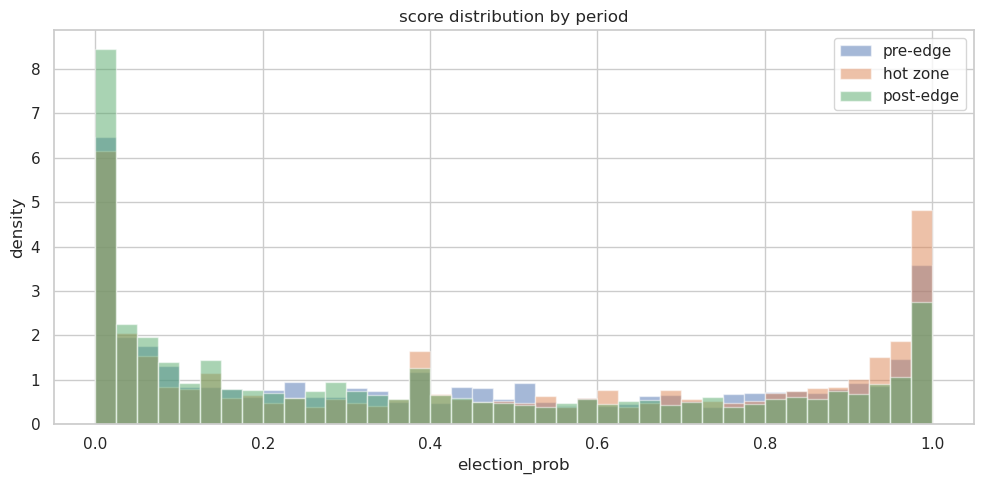

In [13]:
score_pdf = scored.select('ad_creation_date', 'election_prob').toPandas()
score_pdf['period'] = pd.cut(
    pd.to_datetime(score_pdf['ad_creation_date']),
    bins=[WINDOW_START, pd.Timestamp(hot_start), pd.Timestamp(hot_end), WINDOW_END],
    labels=['pre-edge', 'hot zone', 'post-edge'],
)

fig, ax = plt.subplots(figsize=(10, 5))
for period, sub in score_pdf.groupby('period', observed=True):
    ax.hist(sub['election_prob'], bins=40, alpha=0.5, label=period, density=True)
ax.set_xlabel('election_prob')
ax.set_ylabel('density')
ax.set_title('score distribution by period')
ax.legend()
plt.tight_layout()
plt.show()

aggregate per advertiser. for each byline compute total spend and spend-weighted mean election_prob. high mean = advertiser's portfolio is dominated by election content. low mean = mostly non-election content.

In [14]:
from pyspark.sql.functions import sum as spark_sum, avg

per_advertiser = (scored
    .filter(col('bylines').isNotNull() & col('spend_mid').isNotNull())
    .withColumn('weighted_prob', col('election_prob') * col('spend_mid'))
    .groupBy('bylines')
    .agg(
        spark_sum('spend_mid').alias('total_spend'),
        spark_sum('weighted_prob').alias('weighted_prob_sum'),
        spark_count('*').alias('n_ads'),
    )
    .withColumn('mean_election_prob_weighted',
                col('weighted_prob_sum') / col('total_spend'))
    .orderBy(desc('total_spend'))
    .toPandas())

top30 = per_advertiser.head(30).reset_index(drop=True)
display(top30[['bylines', 'total_spend', 'n_ads', 'mean_election_prob_weighted']])

,bylines,total_spend,n_ads,mean_election_prob_weighted
0,Greenpeace Australia Pacific,1539516.5,9567,0.090788
1,Amnesty International Australia,852619.0,2262,0.284426
2,Solutions for Australia,655340.5,1819,0.468546
3,Australian Conservation Foundation,650085.5,2229,0.347166
4,Climate 200,628224.5,1351,0.759127
5,Thrive By Five,612050.0,1100,0.531452
6,Australian Unions,534432.5,535,0.518732
7,Australia for UNHCR,515534.5,1331,0.289801
8,Shell,425398.5,3,0.847631
9,Plan International Australia,377251.5,397,0.189169


per-advertiser per-week aggregation for the top 20. for each (byline, week) compute the spend-weighted election_prob. plot as a small-multiples chart. a pivot pattern looks like a hump around may 2022 for an advertiser whose spend curve in nb 05 looked flat (ongoing).

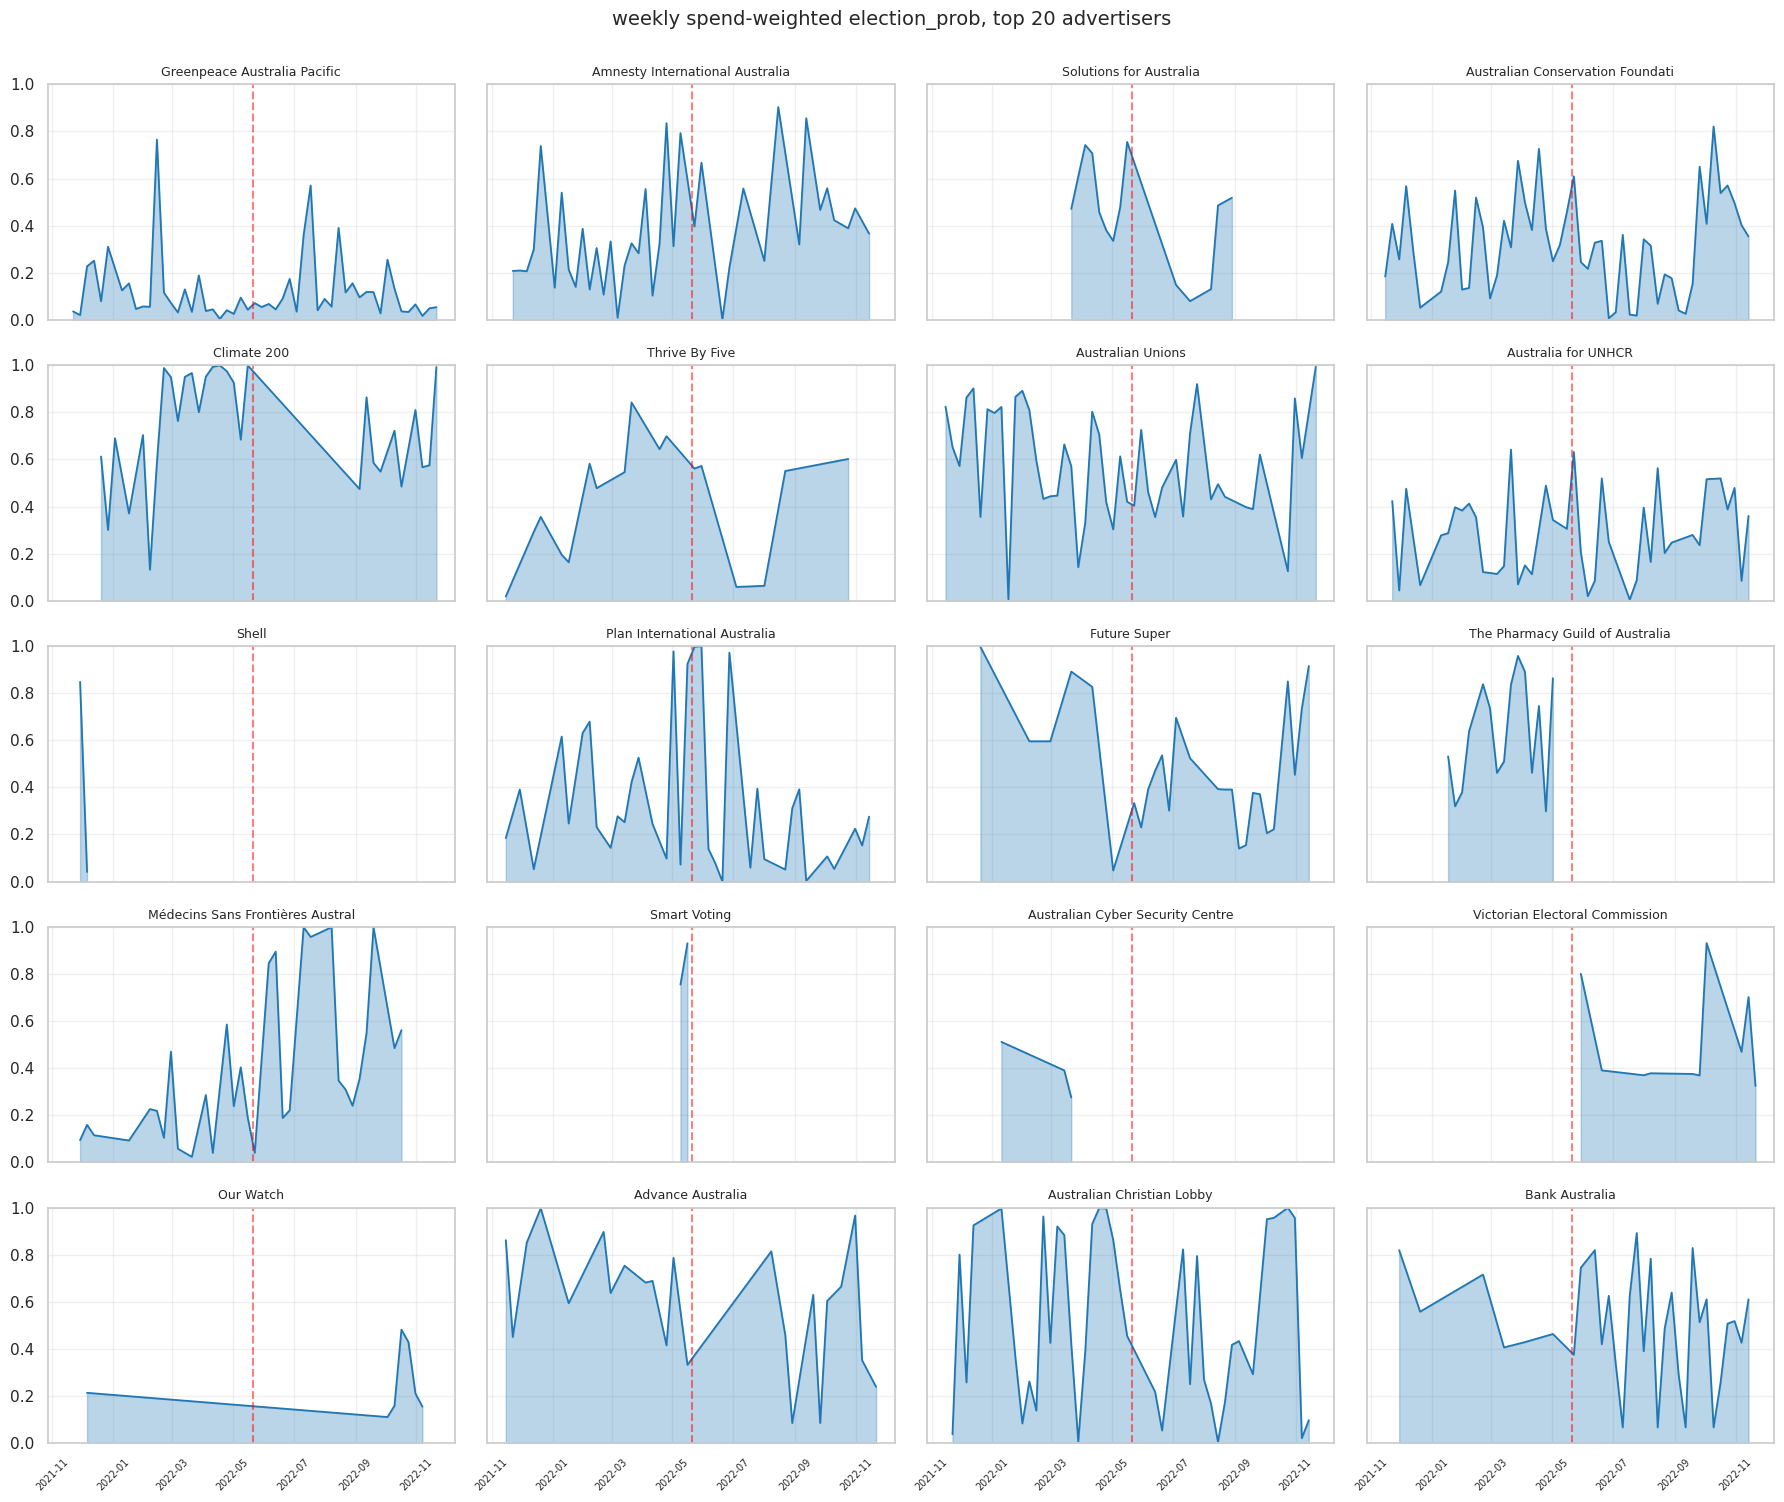

In [15]:
import math

top20_bylines = top30.head(20)['bylines'].tolist()

weekly_scores = (scored
    .filter(col('bylines').isin(top20_bylines) & col('spend_mid').isNotNull())
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .withColumn('weighted_prob', col('election_prob') * col('spend_mid'))
    .groupBy('week', 'bylines')
    .agg(
        spark_sum('weighted_prob').alias('weighted_prob_sum'),
        spark_sum('spend_mid').alias('week_spend'),
    )
    .withColumn('week_election_prob', col('weighted_prob_sum') / col('week_spend'))
    .orderBy('bylines', 'week')
    .toPandas())

weekly_scores['week'] = pd.to_datetime(weekly_scores['week'])

ncols = 4
nrows = math.ceil(len(top20_bylines) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows),
                          sharex=True, sharey=True, squeeze=False)
axes = axes.flatten()

for i, byline in enumerate(top20_bylines):
    ax = axes[i]
    sub = weekly_scores[weekly_scores['bylines'] == byline].sort_values('week')
    ax.plot(sub['week'], sub['week_election_prob'], color='#1f77b4', linewidth=1.3)
    ax.fill_between(sub['week'], sub['week_election_prob'], color='#1f77b4', alpha=0.3)
    ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.5)
    ax.set_title(byline[:32], fontsize=9)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(alpha=0.3)

for j in range(len(top20_bylines), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('weekly spend-weighted election_prob, top 20 advertisers',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

pivot detection. for each advertiser compute the ratio of mean election_prob inside the hot zone vs outside. ratio >> 1 means their content shifted toward election themes around may 2022 even if their overall spend pattern didn't.

In [16]:
from pyspark.sql.functions import mean as spark_mean

advertiser_pivot = (scored
    .filter(col('bylines').isin(top20_bylines))
    .withColumn('in_hot',
                (col('ad_creation_date') >= lit(hot_start)) &
                (col('ad_creation_date') <= lit(hot_end)))
    .groupBy('bylines', 'in_hot')
    .agg(spark_mean('election_prob').alias('mean_prob'),
         spark_count('*').alias('n_ads'))
    .toPandas())

pivot_wide = advertiser_pivot.pivot_table(
    index='bylines', columns='in_hot', values='mean_prob').reset_index()
pivot_wide.columns = ['bylines', 'mean_prob_outside', 'mean_prob_inside']
pivot_wide['shift'] = (pivot_wide['mean_prob_inside'] -
                       pivot_wide['mean_prob_outside'])
pivot_wide['ratio'] = (pivot_wide['mean_prob_inside'] /
                       pivot_wide['mean_prob_outside'].replace(0, np.nan))
pivot_wide = pivot_wide.sort_values('shift', ascending=False).reset_index(drop=True)

display(pivot_wide)

,bylines,mean_prob_outside,mean_prob_inside,shift,ratio
0,Australian Christian Lobby,0.511341,0.818362,0.307021,1.600423
1,Victorian Electoral Commission,0.467627,0.769612,0.301985,1.645782
2,Thrive By Five,0.419028,0.613612,0.194585,1.464371
3,Amnesty International Australia,0.329825,0.520364,0.190539,1.577697
4,Médecins Sans Frontières Australia,0.290090,0.407327,0.117238,1.404142
5,Australian Conservation Foundation,0.304294,0.401519,0.097225,1.319509
6,Plan International Australia,0.270932,0.332541,0.061609,1.227395
7,Climate 200,0.770626,0.810888,0.040262,1.052245
8,Australia for UNHCR,0.227451,0.251254,0.023803,1.104652
9,Bank Australia,0.542244,0.548361,0.006118,1.011282


summary findings. an advertiser landing in ongoing from nb 05 (steady dollar flow) but with a large positive shift here is the pivot pattern we were looking for. an advertiser in election_only with a high mean_prob_inside is consistent with both methodologies.